## Project Name - Strava EDA Analysis

#### Project Type - EDA
#### Contribution - Individual
#### Name - Aditya Thakur

#### Project Summary -
Strava, Inc. is a U.S.-based company that operates a popular fitness tracking and social networking app primarily for cyclists and runners. Founded in 2009 by Mark Gainey and Michael Horvath, Strava allows users to record physical activities using GPS data, analyze performance metrics, and share workouts with a community of athletes. The platform supports various sports and integrates with many fitness devices. Strava is known for features like segments, leaderboards, and challenges, promoting competition and motivation. The company is headquartered in San Francisco, California.

### GitHub Link - https://github.com/adityathakur26

### Problem Statement
###### We have multiple datasets to study the activities of a person using strava, we have to merge all the datasets into one and analyse the dataset using EDA and give solutions for the business problems ?

### Define Your Business Objective?
###### The business objective for Strava datasets are as follows:-

###### 1.To analyze the dataset and find the new trends which attracts more customers to download the app.
###### 2.To analyze the dataset and find how to attract the users to use subsciption model.
###### 3.To analyze the dataset and find the insights for the activities and analyse the behaviour and pattern based on it.
###### 4.To analyze the dataset and find the choices and feedback of customers while using the app.

#### Import Libraries

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### Dataset Loading

In [8]:
daily_activity = pd.read_csv(r'C:\Users\admin\OneDrive\Documents\Strava Fitness\Raw Data\dailyActivity_merged.csv')
daily_calories = pd.read_csv(r'C:\Users\admin\OneDrive\Documents\Strava Fitness\Raw Data\dailyCalories_merged.csv')
daily_steps = pd.read_csv(r'C:\Users\admin\OneDrive\Documents\Strava Fitness\Raw Data\dailySteps_merged.csv')
sleep = pd.read_csv(r'C:\Users\admin\OneDrive\Documents\Strava Fitness\Raw Data\sleepDay_merged.csv')
weight = pd.read_csv(r'C:\Users\admin\OneDrive\Documents\Strava Fitness\Raw Data\weightLoginfo_merged.csv')

#### Checking Missing Values/Null Values

In [9]:
daily_activity.isnull().sum()

Id                          0
ActivityDate                0
TotalSteps                  0
TotalDistance               0
TrackerDistance             0
LoggedActivitiesDistance    0
VeryActiveDistance          0
ModeratelyActiveDistance    0
LightActiveDistance         0
SedentaryActiveDistance     0
VeryActiveMinutes           0
FairlyActiveMinutes         0
LightlyActiveMinutes        0
SedentaryMinutes            0
Calories                    0
dtype: int64

In [10]:
daily_activity.duplicated().sum()

np.int64(0)

In [11]:
daily_calories.isnull().sum()

Id             0
ActivityDay    0
Calories       0
dtype: int64

In [12]:
daily_calories.duplicated().sum()

np.int64(0)

In [13]:
daily_steps.isnull().sum()

Id             0
ActivityDay    0
StepTotal      0
dtype: int64

In [14]:
daily_steps.duplicated().sum()

np.int64(0)

In [15]:
sleep.isnull().sum()

Id                    0
SleepDay              0
TotalSleepRecords     0
TotalMinutesAsleep    0
TotalTimeInBed        0
dtype: int64

In [16]:
sleep.duplicated().sum()

np.int64(3)

In [17]:
weight.isnull().sum()

Id                 0
Date               0
WeightKg           0
WeightPounds       0
Fat               65
BMI                0
IsManualReport     0
LogId              0
dtype: int64

In [18]:
weight.duplicated().sum()

np.int64(0)

In [19]:
daily_activity.columns

Index(['Id', 'ActivityDate', 'TotalSteps', 'TotalDistance', 'TrackerDistance',
       'LoggedActivitiesDistance', 'VeryActiveDistance',
       'ModeratelyActiveDistance', 'LightActiveDistance',
       'SedentaryActiveDistance', 'VeryActiveMinutes', 'FairlyActiveMinutes',
       'LightlyActiveMinutes', 'SedentaryMinutes', 'Calories'],
      dtype='object')

In [20]:
daily_activity['ActivityDate'] = pd.to_datetime(daily_activity['ActivityDate'])

In [21]:
daily_activity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 940 entries, 0 to 939
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Id                        940 non-null    int64         
 1   ActivityDate              940 non-null    datetime64[ns]
 2   TotalSteps                940 non-null    int64         
 3   TotalDistance             940 non-null    float64       
 4   TrackerDistance           940 non-null    float64       
 5   LoggedActivitiesDistance  940 non-null    float64       
 6   VeryActiveDistance        940 non-null    float64       
 7   ModeratelyActiveDistance  940 non-null    float64       
 8   LightActiveDistance       940 non-null    float64       
 9   SedentaryActiveDistance   940 non-null    float64       
 10  VeryActiveMinutes         940 non-null    int64         
 11  FairlyActiveMinutes       940 non-null    int64         
 12  LightlyActiveMinutes  

In [22]:
sleep.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 413 entries, 0 to 412
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Id                  413 non-null    int64 
 1   SleepDay            413 non-null    object
 2   TotalSleepRecords   413 non-null    int64 
 3   TotalMinutesAsleep  413 non-null    int64 
 4   TotalTimeInBed      413 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 16.3+ KB


In [40]:
sleep['SleepDay'] = pd.to_datetime(sleep['SleepDay'], format='%m/%d/%Y %I:%M:%S %p').dt.date

In [41]:
sleep.duplicated().sum()

np.int64(0)

In [42]:
sleep = sleep.drop_duplicates()

In [43]:
weight.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67 entries, 0 to 66
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Id              67 non-null     int64         
 1   Date            67 non-null     datetime64[ns]
 2   WeightKg        67 non-null     float64       
 3   BMI             67 non-null     float64       
 4   IsManualReport  67 non-null     bool          
 5   LogId           67 non-null     int64         
dtypes: bool(1), datetime64[ns](1), float64(2), int64(2)
memory usage: 2.8 KB


In [46]:
weight['Date'] = pd.to_datetime(weight['Date'], format='%m/%d/%Y %I:%M:%S %p').dt.date

In [47]:
weight.duplicated().sum()

np.int64(0)

In [48]:
weight.isnull().sum()

Id                0
Date              0
WeightKg          0
BMI               0
IsManualReport    0
LogId             0
dtype: int64

In [51]:
weight_bmi = weight.dropna(subset=['BMI'])

In [52]:
daily_calories['ActivityDay'] = pd.to_datetime(daily_calories['ActivityDay'])
daily_steps['ActivityDay'] = pd.to_datetime(daily_steps['ActivityDay'])

### Merging Dataset

#### DataFrame 1

In [ ]:
activity_df = daily_activity.merge(
    daily_calories,
    left_on=['Id', 'ActivityDate'],
    right_on=['Id', 'ActivityDay'],
    how='left'
)

activity_df = activity_df.merge(
    daily_steps,
    left_on=['Id', 'ActivityDate'],
    right_on=['Id', 'ActivityDay'],
    how='left'
)

In [ ]:
activity_df.info()

#### DataFrame 2

In [63]:
sleep_clean = sleep.drop_duplicates()

In [64]:
sleep_activity_df = daily_activity.merge(
    sleep_clean,
    left_on=['Id', 'ActivityDate'],
    right_on=['Id', 'SleepDay'],
    how='left'
)

In [65]:
sleep['SleepDay'] = pd.to_datetime(sleep['SleepDay'])
daily_activity['ActivityDate'] = pd.to_datetime(daily_activity['ActivityDate'])

In [66]:
sleep_activity_df['SleepTracked'] = sleep_activity_df['TotalMinutesAsleep'].notnull().astype(int)

In [67]:
print(daily_activity['ActivityDate'].dtype)
print(sleep_clean['SleepDay'].dtype)

datetime64[ns]
datetime64[ns]


#### DataFrame 3

In [68]:
body_metrics_df = daily_activity.merge(
    weight,
    left_on=['Id'],
    right_on=['Id'],
    how='inner'
)

In [69]:
print("Activity DF shape:", activity_df.shape)
print("Sleep-Activity DF shape:", sleep_activity_df.shape)
print("Body Metrics DF shape:", body_metrics_df.shape)

Activity DF shape: (940, 17)
Sleep-Activity DF shape: (940, 20)
Body Metrics DF shape: (2076, 20)


#### Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables

#### 1. Activity Behaviour

##### What is the average number of daily steps taken by users?

In [70]:
avg_daily_steps = activity_df.groupby('Id')['TotalSteps'].mean()
avg_daily_steps.describe()

count       33.000000
mean      7519.272678
std       3576.340125
min        916.129032
25%       5566.870968
50%       7282.966667
75%       9519.666667
max      16040.032258
Name: TotalSteps, dtype: float64

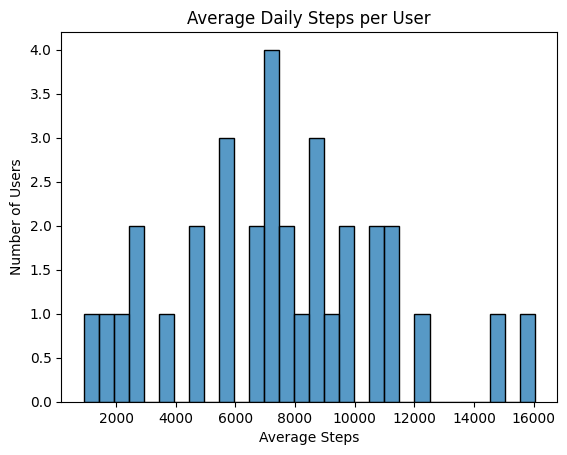

In [71]:
plt.figure()
sns.histplot(avg_daily_steps, bins=30)
plt.title('Average Daily Steps per User')
plt.xlabel('Average Steps')
plt.ylabel('Number of Users')
plt.show()

##### How many users fall into sedentary, moderately active, and highly active categories?

In [72]:
def activity_category(steps):
    if steps < 5000:
        return 'Sedentary'
    elif steps < 10000:
        return 'Moderately Active'
    else:
        return 'Highly Active'

activity_df['ActivityCategory'] = activity_df['TotalSteps'].apply(activity_category)

user_activity_category = (
    activity_df.groupby('Id')['ActivityCategory']
    .agg(lambda x: x.value_counts().idxmax())
)

user_activity_category.value_counts()

ActivityCategory
Moderately Active    14
Highly Active        11
Sedentary             8
Name: count, dtype: int64

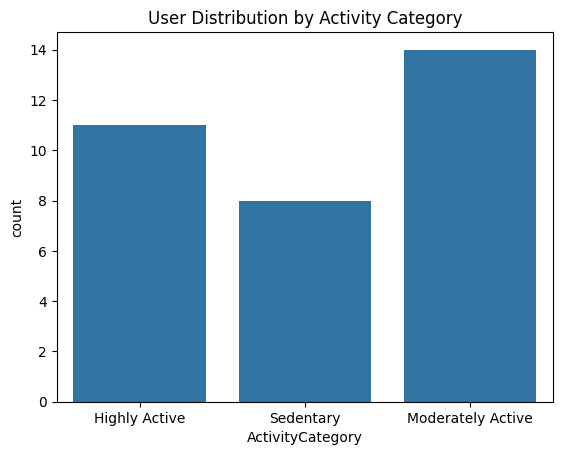

In [73]:
sns.countplot(x=user_activity_category)
plt.title('User Distribution by Activity Category')
plt.show()

##### How does sedentary time compare with active minutes across users?

In [74]:
activity_df['TotalActiveMinutes'] = (
    activity_df['VeryActiveMinutes'] +
    activity_df['FairlyActiveMinutes'] +
    activity_df['LightlyActiveMinutes']
)

sedentary_vs_active = activity_df[['SedentaryMinutes', 'TotalActiveMinutes']].mean()
sedentary_vs_active

SedentaryMinutes      991.210638
TotalActiveMinutes    227.542553
dtype: float64

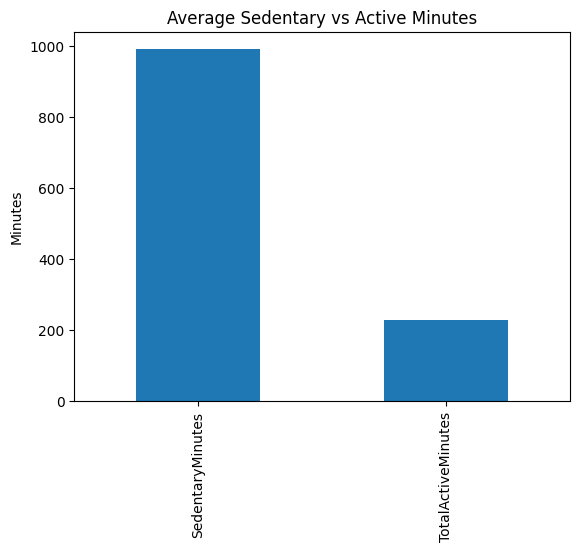

In [75]:
sedentary_vs_active.plot(kind='bar')
plt.title('Average Sedentary vs Active Minutes')
plt.ylabel('Minutes')
plt.show()

#### 2. Energy Expenditure

##### What is the average daily calorie burn per user?

In [80]:
activity_df.columns

Index(['Id', 'ActivityDate', 'TotalSteps', 'TotalDistance', 'TrackerDistance',
       'LoggedActivitiesDistance', 'VeryActiveDistance',
       'ModeratelyActiveDistance', 'LightActiveDistance',
       'SedentaryActiveDistance', 'VeryActiveMinutes', 'FairlyActiveMinutes',
       'LightlyActiveMinutes', 'SedentaryMinutes', 'Calories_x', 'Calories_y',
       'StepTotal', 'ActivityCategory', 'TotalActiveMinutes'],
      dtype='object')

In [82]:
activity_df = activity_df.drop(columns=['Calories_y']).rename(columns={'Calories_x': 'Calories'})

In [83]:
avg_daily_calories = activity_df.groupby('Id')['Calories'].mean()
avg_daily_calories.describe()

count      33.000000
mean     2282.443660
std       562.761632
min      1483.354839
25%      1916.967742
50%      2131.769231
75%      2599.620690
max      3436.580645
Name: Calories, dtype: float64

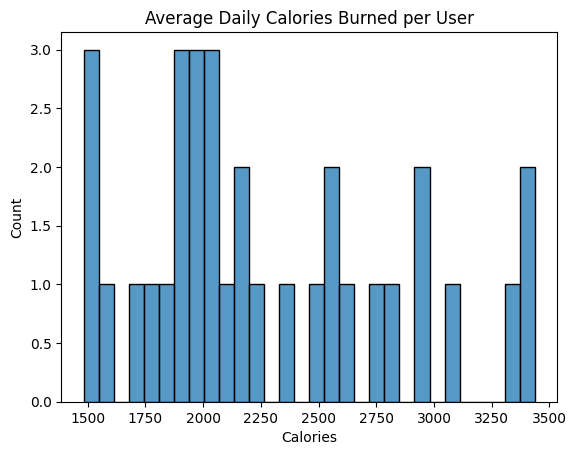

In [84]:
sns.histplot(avg_daily_calories, bins=30)
plt.title('Average Daily Calories Burned per User')
plt.show()

##### How does calorie burn vary across different days of the week?

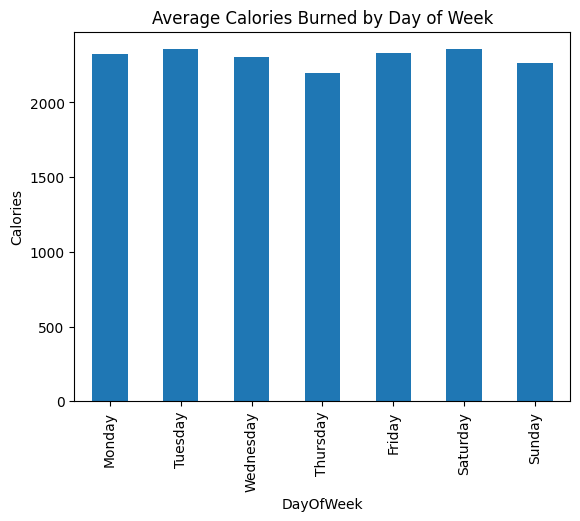

In [85]:
activity_df['DayOfWeek'] = pd.to_datetime(activity_df['ActivityDate']).dt.day_name()

calories_by_day = activity_df.groupby('DayOfWeek')['Calories'].mean()
calories_by_day
calories_by_day.reindex([
    'Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'
]).plot(kind='bar')

plt.title('Average Calories Burned by Day of Week')
plt.ylabel('Calories')
plt.show()

##### Are there users with consistently low calorie burn despite daily activity?

In [86]:
user_calorie_stats = activity_df.groupby('Id').agg(
    avg_steps=('TotalSteps', 'mean'),
    avg_calories=('Calories', 'mean')
)

low_calorie_active_users = user_calorie_stats[
    (user_calorie_stats['avg_steps'] > 7000) &
    (user_calorie_stats['avg_calories'] < user_calorie_stats['avg_calories'].quantile(0.25))
]

low_calorie_active_users.head()

,avg_steps,avg_calories
Id,,
1503960366,12116.741935,1816.419355
3977333714,10984.566667,1513.666667
5553957443,8612.580645,1875.677419


#### 3. Mobility Patterns

###### What percentage of users meet the recommended 10,000 steps per day?

In [87]:
steps_10k = activity_df.groupby('Id')['TotalSteps'].mean()

percentage_10k = (steps_10k >= 10000).mean() * 100
percentage_10k

np.float64(21.21212121212121)

##### How consistent are users in achieving daily step goals?

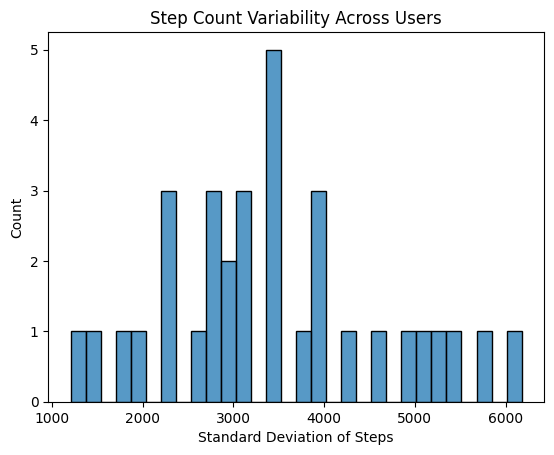

In [88]:
step_consistency = activity_df.groupby('Id')['TotalSteps'].std()
step_consistency.describe()
sns.histplot(step_consistency, bins=30)
plt.title('Step Count Variability Across Users')
plt.xlabel('Standard Deviation of Steps')
plt.show()

##### Are there noticeable drops in steps on weekends or weekdays?

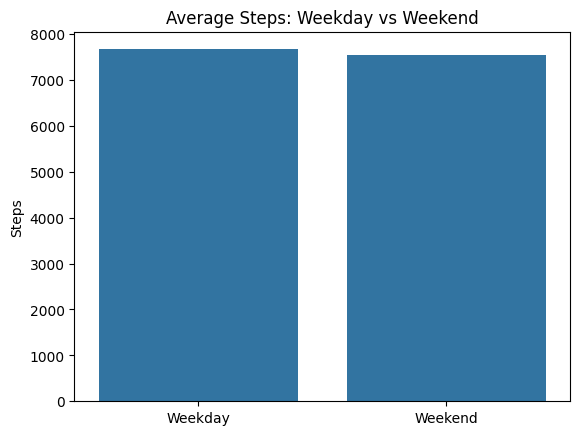

In [89]:
activity_df['IsWeekend'] = activity_df['DayOfWeek'].isin(['Saturday', 'Sunday'])

weekend_steps = activity_df.groupby('IsWeekend')['TotalSteps'].mean()
weekend_steps

sns.barplot(
    x=['Weekday', 'Weekend'],
    y=weekend_steps.values
)
plt.title('Average Steps: Weekday vs Weekend')
plt.ylabel('Steps')
plt.show()

#### Sleep Behavior

##### What is the average sleep duration per user?

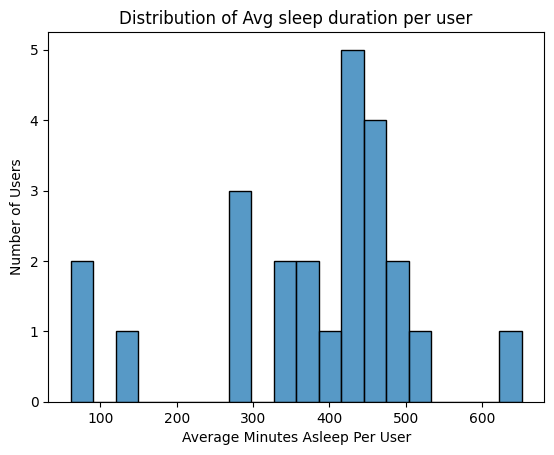

In [90]:
avg_sleep_per_user = sleep.groupby('Id')['TotalMinutesAsleep'].mean()
avg_sleep_per_user.describe()

plt.figure()
sns.histplot(avg_sleep_per_user, bins = 20)
plt.xlabel('Average Minutes Asleep Per User')
plt.ylabel('Number of Users')
plt.title('Distribution of Avg sleep duration per user')
plt.show()

##### How many users get less than the recommended 7 hours of sleep?

In [91]:
users_less_7hrs = (avg_sleep_per_user < 420).sum()
total_sleep_users = avg_sleep_per_user.count()

users_less_7hrs, total_sleep_users

percentage_less_7hrs = (users_less_7hrs / total_sleep_users) * 100
percentage_less_7hrs

np.float64(54.166666666666664)

##### Is sleep efficiency (time asleep vs time in bed) consistent across users?

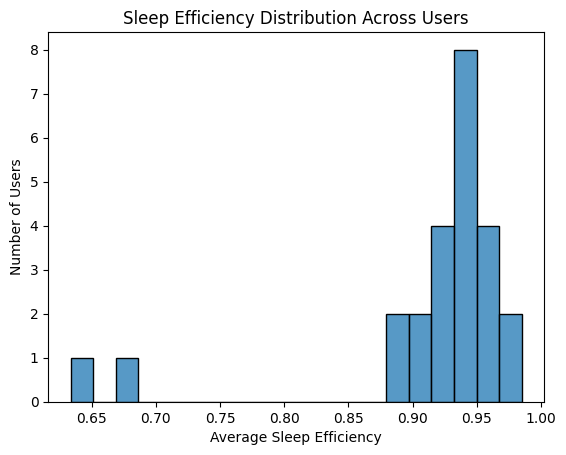

In [92]:
sleep['SleepEfficiency'] = (
    sleep['TotalMinutesAsleep'] / sleep['TotalTimeInBed']
)
sleep_efficiency_user = (
    sleep.groupby('Id')['SleepEfficiency']
    .mean()
)

sleep_efficiency_user.describe()
plt.figure()
sns.histplot(sleep_efficiency_user, bins=20)
plt.xlabel('Average Sleep Efficiency')
plt.ylabel('Number of Users')
plt.title('Sleep Efficiency Distribution Across Users')
plt.show()

#### BMI / Body Metrics

##### What is the BMI distribution among users?

In [93]:
bmi_per_user = (
    body_metrics_df.groupby('Id')['BMI']
    .mean()
)

bmi_per_user.describe()

count     8.000000
mean     27.988011
std       8.236066
min      21.570001
25%      23.683500
50%      26.350542
75%      27.561250
max      47.540001
Name: BMI, dtype: float64

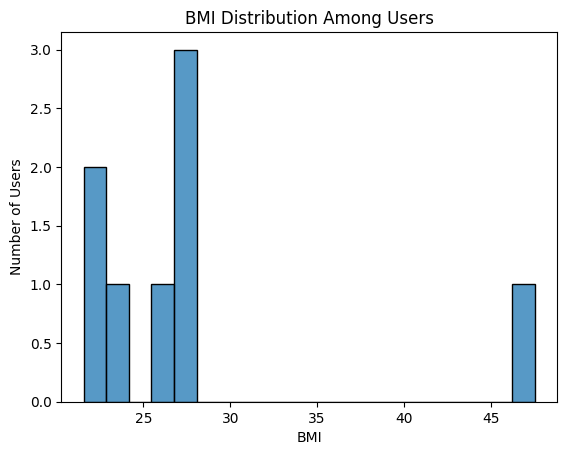

In [94]:
plt.figure()
sns.histplot(bmi_per_user, bins=20)
plt.xlabel('BMI')
plt.ylabel('Number of Users')
plt.title('BMI Distribution Among Users')
plt.show()

##### Are users with higher BMI logging weight more frequently?


In [95]:
weight_logs = (
    weight.groupby('Id')
    .size()
    .reset_index(name='LogCount')
)
bmi_logs_df = weight.merge(
    weight_logs,
    on='Id',
    how='inner'
)

bmi_logs_df[['BMI', 'LogCount']].corr()

,BMI,LogCount
BMI,1.00000,-0.39537
LogCount,-0.39537,1.00000


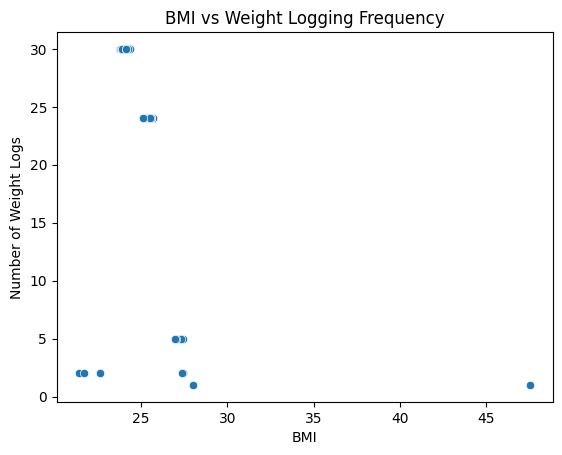

In [96]:
plt.figure()
sns.scatterplot(
    data=bmi_logs_df,
    x='BMI',
    y='LogCount'
)
plt.xlabel('BMI')
plt.ylabel('Number of Weight Logs')
plt.title('BMI vs Weight Logging Frequency')
plt.show()

##### Is there any visible trend in weight change over time?

In [97]:
weight_sorted = weight.sort_values(['Id', 'Date'])

weight_sorted['WeightChange'] = (
    weight_sorted.groupby('Id')['WeightKg']
    .diff()
)

weight_sorted[['WeightChange']].dropna().describe()

,WeightChange
count,59.000000
mean,-0.042373
std,0.469851
min,-1.400002
25%,-0.400000
50%,-0.099998
75%,0.200001
max,1.200001


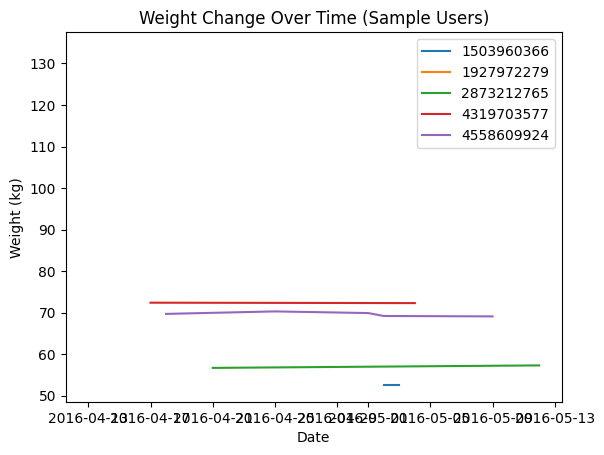

In [98]:
sample_users = weight_sorted['Id'].unique()[:5]

plt.figure()
for user in sample_users:
    user_data = weight_sorted[weight_sorted['Id'] == user]
    plt.plot(user_data['Date'], user_data['WeightKg'], label=str(user))

plt.xlabel('Date')
plt.ylabel('Weight (kg)')
plt.title('Weight Change Over Time (Sample Users)')
plt.legend()
plt.show()

### Merged DataFrames Visualization

##### 1. How does daily activity (steps and intensity) impact calories burned?

In [99]:
activity_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 940 entries, 0 to 939
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Id                        940 non-null    int64         
 1   ActivityDate              940 non-null    datetime64[ns]
 2   TotalSteps                940 non-null    int64         
 3   TotalDistance             940 non-null    float64       
 4   TrackerDistance           940 non-null    float64       
 5   LoggedActivitiesDistance  940 non-null    float64       
 6   VeryActiveDistance        940 non-null    float64       
 7   ModeratelyActiveDistance  940 non-null    float64       
 8   LightActiveDistance       940 non-null    float64       
 9   SedentaryActiveDistance   940 non-null    float64       
 10  VeryActiveMinutes         940 non-null    int64         
 11  FairlyActiveMinutes       940 non-null    int64         
 12  LightlyActiveMinutes  

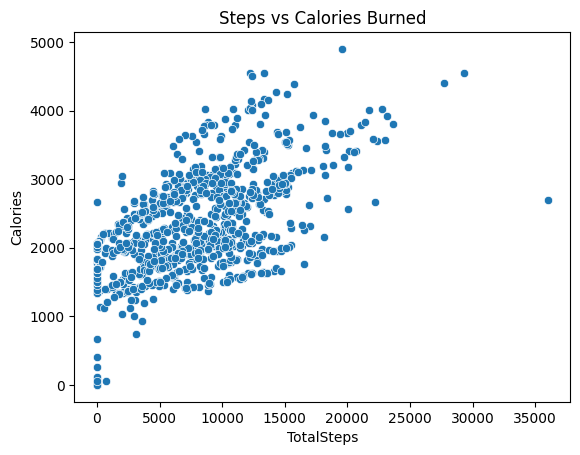

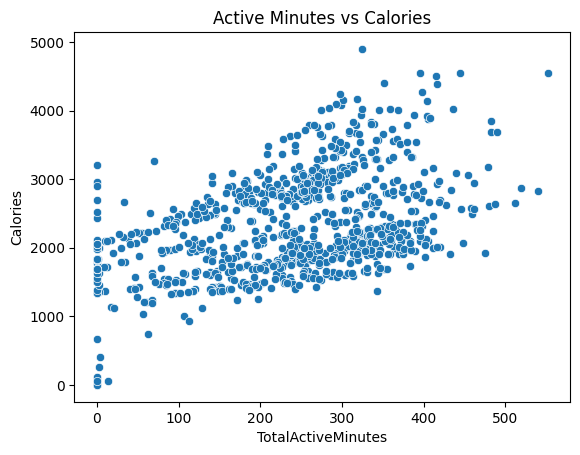

In [100]:
# Correlation
activity_df[['TotalSteps', 'Calories']].corr()
# Scatter plot
plt.figure()
sns.scatterplot(data=activity_df, x='TotalSteps', y='Calories')
plt.title('Steps vs Calories Burned')
plt.show()
# Calories by activity intensity
activity_df['TotalActiveMinutes'] = (
    activity_df['VeryActiveMinutes'] +
    activity_df['FairlyActiveMinutes'] +
    activity_df['LightlyActiveMinutes']
)

sns.scatterplot(
    data=activity_df,
    x='TotalActiveMinutes',
    y='Calories'
)
plt.title('Active Minutes vs Calories')
plt.show()

##### Q2. Is there a relationship between sleep duration and next-day activity levels?

In [101]:
sleep_activity_df['TotalMinutesAsleep'].notnull().sum()

np.int64(410)

In [102]:
sleep_user = sleep.groupby('Id')['TotalMinutesAsleep'].mean().reset_index()

In [103]:
activity_user = daily_activity.groupby('Id')['TotalSteps'].mean().reset_index()

In [104]:
q2_df = sleep_user.merge(activity_user, on='Id', how='inner')
q2_df.shape

(24, 3)

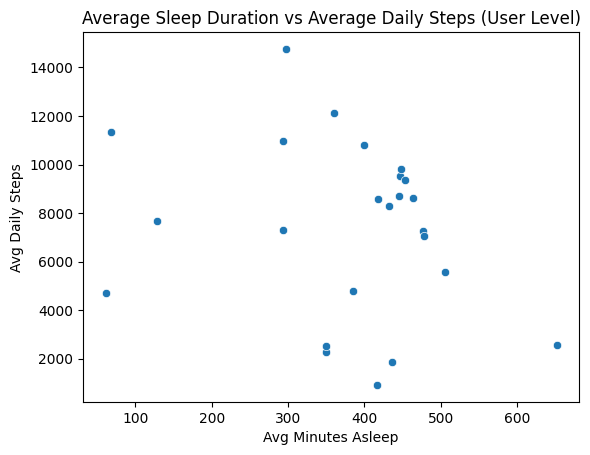

In [105]:
sns.scatterplot(
    data=q2_df,
    x='TotalMinutesAsleep',
    y='TotalSteps'
)

plt.title('Average Sleep Duration vs Average Daily Steps (User Level)')
plt.xlabel('Avg Minutes Asleep')
plt.ylabel('Avg Daily Steps')
plt.show()

##### Q3. Are users who track sleep more consistent in their daily activity compared to non-sleep trackers?

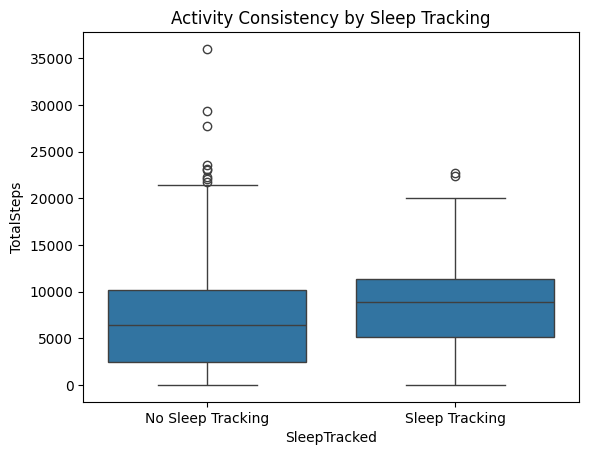

In [106]:
sleep_consistency = sleep_activity_df.groupby('SleepTracked')['TotalSteps'].agg(
    ['mean', 'std']
)
sleep_consistency
sns.boxplot(
    data=sleep_activity_df,
    x='SleepTracked',
    y='TotalSteps'
)
plt.xticks([0, 1], ['No Sleep Tracking', 'Sleep Tracking'])
plt.title('Activity Consistency by Sleep Tracking')
plt.show()

##### Q4. How does BMI vary with activity level and calorie expenditure?

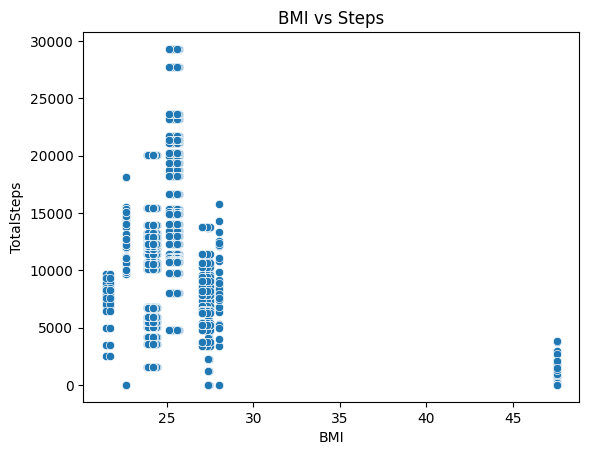

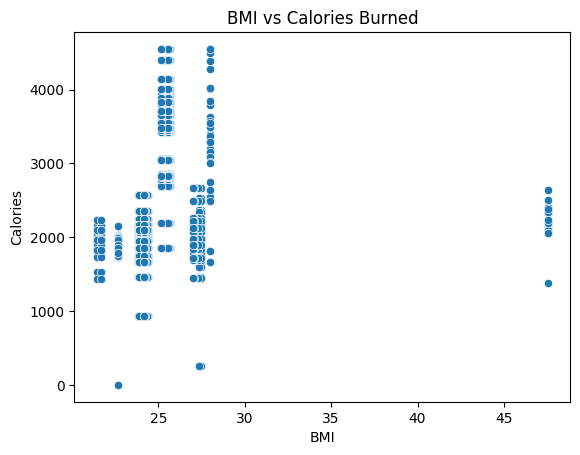

In [107]:
body_metrics_df[['BMI', 'TotalSteps', 'Calories']].corr()
sns.scatterplot(
    data=body_metrics_df,
    x='BMI',
    y='TotalSteps'
)
plt.title('BMI vs Steps')
plt.show()
sns.scatterplot(
    data=body_metrics_df,
    x='BMI',
    y='Calories'
)
plt.title('BMI vs Calories Burned')
plt.show()

##### Q5. Can users be segmented into behavioral groups based on activity, sleep, and BMI patterns?

In [110]:
segmentation_df = sleep_activity_df.merge(
    body_metrics_df[['Id', 'BMI']],
    on='Id',
    how='left'
)

In [111]:
segmentation_df.shape

(65019, 21)

In [113]:
def segment_user(row):
    if row['TotalSteps'] < 5000:
        return 'Sedentary'
    elif row['TotalSteps'] < 10000:
        return 'Moderately Active'
    else:
        return 'Highly Active'

segmentation_df['UserSegment'] = segmentation_df.apply(segment_user, axis=1)

In [114]:
segmentation_df[['UserSegment', 'BMI']].isnull().sum()

UserSegment      0
BMI            693
dtype: int64

In [115]:
bmi_plot_df = segmentation_df.dropna(subset=['BMI'])

In [116]:
bmi_plot_df.shape

(64326, 22)

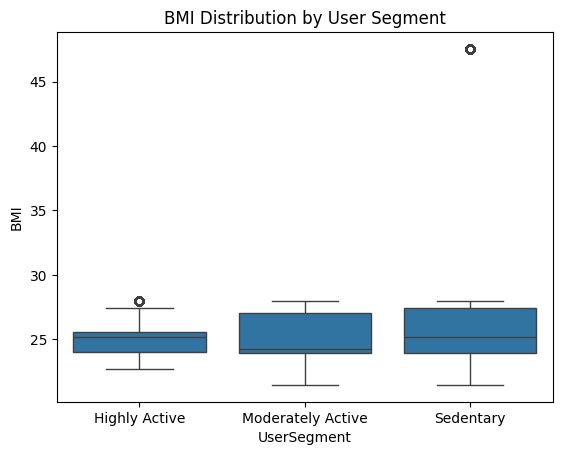

In [117]:
sns.boxplot(
    data=bmi_plot_df,
    x='UserSegment',
    y='BMI'
)

plt.title('BMI Distribution by User Segment')
plt.show()

In [118]:
activity_df.to_csv("daily_activity.csv", index=False)

In [145]:
activity_df.count()

Id                          940
ActivityDate                940
TotalSteps                  940
TotalDistance               940
TrackerDistance             940
LoggedActivitiesDistance    940
VeryActiveDistance          940
ModeratelyActiveDistance    940
LightActiveDistance         940
SedentaryActiveDistance     940
VeryActiveMinutes           940
FairlyActiveMinutes         940
LightlyActiveMinutes        940
SedentaryMinutes            940
Calories                    940
StepTotal                   940
ActivityCategory            940
TotalActiveMinutes          940
DayOfWeek                   940
IsWeekend                   940
dtype: int64

In [119]:
sleep_activity_df.to_csv("sleep_day.csv", index=False)

In [146]:
sleep_activity_df.count()

Id                          940
ActivityDate                940
TotalSteps                  940
TotalDistance               940
TrackerDistance             940
LoggedActivitiesDistance    940
VeryActiveDistance          940
ModeratelyActiveDistance    940
LightActiveDistance         940
SedentaryActiveDistance     940
VeryActiveMinutes           940
FairlyActiveMinutes         940
LightlyActiveMinutes        940
SedentaryMinutes            940
Calories                    940
SleepDay                    410
TotalSleepRecords           410
TotalMinutesAsleep          410
TotalTimeInBed              410
SleepTracked                940
dtype: int64

In [120]:
body_metrics_df.to_csv("body_metrics.csv", index=False)

In [131]:
body_metrics_df.shape

(2076, 20)

In [147]:
df = pd.read_csv(r'C:\Users\admin\OneDrive\Documents\Strava Fitness\sleep_day.csv')

In [148]:
df.count()

Id                          940
ActivityDate                940
TotalSteps                  940
TotalDistance               940
TrackerDistance             940
LoggedActivitiesDistance    940
VeryActiveDistance          940
ModeratelyActiveDistance    940
LightActiveDistance         940
SedentaryActiveDistance     940
VeryActiveMinutes           940
FairlyActiveMinutes         940
LightlyActiveMinutes        940
SedentaryMinutes            940
Calories                    940
SleepDay                    410
TotalSleepRecords           410
TotalMinutesAsleep          410
TotalTimeInBed              410
SleepTracked                940
dtype: int64

#### Solution to Business Objective

###### To achieve the business objective of improving marketing strategy using smart fitness tracker data, the client should adopt a behavior-driven and personalized engagement approach rather than a generic one.

###### Leverage activity-based segmentation:
Segment users into sedentary, moderately active, and highly active groups based on daily steps and activity minutes. This enables targeted campaigns such as motivational nudges for sedentary users and performance challenges for active users.

###### Promote step-based challenges and streaks:
Since steps strongly correlate with calorie burn, step goals, leaderboards, and streak rewards should be the core engagement tools to increase daily activity and retention.

###### Position sleep tracking as an engagement feature:
Users who track sleep show higher activity consistency. Promote sleep tracking as part of a holistic wellness experience rather than focusing only on sleep duration outcomes.

###### Use supportive messaging for BMI and weight tracking:
Higher BMI users tend to log weight less frequently. Introduce non-judgmental reminders, progress-focused insights, and optional tracking to improve adoption without discouraging users.

###### Adopt personalization over one-size-fits-all marketing:
Combine activity, sleep tracking behavior, and BMI availability to deliver personalized notifications, recommendations, and content tailored to individual user behavior patterns.

#### Conclusion

The analysis of smart fitness tracker data shows that daily activity levels, especially step count and active minutes, are the primary drivers of calorie expenditure.

Sleep tracking behaviour reflects user engagement, though sleep duration alone does not strongly impact activity levels.

BMI and weight data indicate varying levels of user participation, highlighting the need for supportive and personalized engagement strategies. 

Overall, activity-based user segmentation enables more effective marketing, improved feature adoption, and better user retention.